<div style="background-color:#A299CA; 
            color:white; 
            padding:15px; 
            border-radius:10px; 
            text-align:center; 
            font-size:30px; 
            font-weight:bold;">
    Human Emotion Classification<br>
    <span style="font-size:20px; font-weight:normal;">
        Group 5: Martha Brenner, Paulo Magalhães, Anna Grenz
    </span>
</div>

<div style="background-color:#EBE9F8;
            color:#333333;
            padding:12px 16px;
            border-radius:10px;
            margin:10px 0;">
   </b> 

<h1 id="setup" 
    style="font-size:30px;
           background-color:#EBE9F8;
           color:#A299CA;
           font-weight:bold;
           padding:10px;
           border-radius:10px;">
    Introduction
</h1>

<div style="background-color:#F0EFFB;
            color:#333333;
            padding:12px 16px;
            border-radius:10px;
            margin:10px 0;">
   </b> 

The dataset used in this competition originates from the Extended Cohn–Kanade (CK+) database, a well-known benchmark collection for facial expression recognition (Lucey et al., 2010). It consists of cropped grayscale photographs of 101 adult participants, aged between 18 and 50, who were instructed by experimenters to deliberately perform specific facial expressions corresponding to validated emotion categories. In this version of the dataset, the images have been preprocessed to tightly frame the faces and include four emotions: anger, disgust, happiness, and sadness. Emotion labels were verified by trained emotion researchers based on combinations of Facial Action Units (AUs), which represent the activation of distinct muscle groups in the human face. Because the data were collected in a highly controlled laboratory environment with mostly Euro-American participants, the results of any model trained on this dataset will generalize primarily to similar, clearly posed, frontal facial expressions taken under controlled lighting conditions. It is unlikely to generalize well to spontaneous, subtle, or real-world expressions in diverse populations.

Candidate machine learning methods for this task include both classical statistical and modern regularized approaches as introduced in ISLR Chapters 1–9 and 12. Suitable models include logistic regression, linear or quadratic discriminant analysis (LDA/QDA), k-nearest neighbors, decision trees, random forests, gradient boosting, and support vector machines. Because facial images are high-dimensional, it is effective to reduce the number of features using principal component analysis (PCA) to create so-called eigenfaces, or to summarize images through simple statistical measures such as mean brightness, variance, and average edge strength. Combining PCA features with a linear or radial-basis-function SVM, or alternatively using LDA on PCA-reduced data, is a well-established and robust approach for this type of dataset.

The Bayes error rate represents the theoretical lower limit of misclassification that no model can surpass, given natural overlap between the emotion categories. Although the exact bound is unknown, evidence from the scientific literature on CK+ suggests that the best-performing models, such as deep convolutional neural networks trained on similar data, reach around 97–99 percent accuracy. This implies an estimated Bayes error rate of roughly 1–3 percent. However, this estimated 97–99 percent accuracy is likely unrealistic, as it assumes near-perfect conditions rarely achieved in real-world by humans. In other words, even an optimal classifier cannot achieve perfect performance due to the intrinsic ambiguity and subtle similarity between some emotional expressions.


</div>

</div>


<h1 id = setup style = 'font-size:30px; background: linear-gradient(90deg, #B8B1D8, #B8B1D8, #E5E3F4); color: white; padding: 10px;  border-radius: 10px;'>
    1. Loading Data
</h1


In [1]:
## Importing packages
suppressMessages(library(tidyverse)) # metapackage with lots of helpful functions
suppressMessages(library(png)) # package that can be used to read png image files in a simple format
suppressMessages(library(caret))
suppressMessages(library(glmnet))
suppressMessages(library(ranger))
suppressMessages(library(xgboost))

## Reading in files
list.files(path = "../input/")

[1] "bda-2025-human-faces"

In [2]:
# Show the availabe directories
dirs = dir("../input", pattern="[^g]$", recursive=TRUE, include.dirs = TRUE, full.names = TRUE)
dirs

[1] "../input/bda-2025-human-faces"                     
[2] "../input/bda-2025-human-faces/ckplus"              
[3] "../input/bda-2025-human-faces/ckplus/test"         
[4] "../input/bda-2025-human-faces/ckplus/train"        
[5] "../input/bda-2025-human-faces/ckplus/train/anger"  
[6] "../input/bda-2025-human-faces/ckplus/train/disgust"
[7] "../input/bda-2025-human-faces/ckplus/train/happy"  
[8] "../input/bda-2025-human-faces/ckplus/train/sadness"

In [3]:
# Get all image files: file names ending ".png" 
anger   = dir(grep("anger",   dirs, value = TRUE), pattern = "png$", full.names = TRUE)
disgust = dir(grep("disgust", dirs, value = TRUE), pattern = "png$", full.names = TRUE)
happy   = dir(grep("happy",   dirs, value = TRUE), pattern = "png$", full.names = TRUE)
sad     = dir(grep("sad",     dirs, value = TRUE), pattern = "png$", full.names = TRUE)
test_im = dir(grep("test",    dirs, value = TRUE), pattern = "png$", full.names = TRUE)

str(anger)
str(disgust)
str(happy)
str(sad)
str(test_im)

 chr [1:570] "../input/bda-2025-human-faces/ckplus/train/anger/S010_004_00000018a.png" ...
 chr [1:744] "../input/bda-2025-human-faces/ckplus/train/disgust/S005_001_00000009a.png" ...
 chr [1:870] "../input/bda-2025-human-faces/ckplus/train/happy/S010_006_00000013a.png" ...
 chr [1:354] "../input/bda-2025-human-faces/ckplus/train/sadness/S011_002_00000020a.png" ...
 chr [1:1080] "../input/bda-2025-human-faces/ckplus/test/S010_004_00000017a.png" ...


<h1 id = setup style = 'font-size:30px; background: linear-gradient(90deg, #B8B1D8, #B8B1D8, #E5E3F4); color: white; padding: 10px;  border-radius: 10px;'>
    2. Data Preparation
</h1


In [4]:
# Combine all filenames into a single vector
train_image_files = c(anger, happy, sad, disgust)

# Read in the images as pixel values (discarding color channels)
X = sapply(train_image_files, function(nm) c(readPNG(nm)[,,1])) %>% t()

# Create labels for the training images
y = c(rep("anger",   length(anger)),
      rep("happy",   length(happy)),
      rep("sad",     length(sad)),
      rep("disgust", length(disgust)))

# Process test images in the same way as the training images
X_test = sapply(test_im, function(nm) c(readPNG(nm)[,,1])) %>% t()

# Change row and column names of X to something more manageable (caret::train requires column names)
rownames(X)      = gsub(".+train/", "", rownames(X))
rownames(X_test) = gsub(".+test/",  "", rownames(X_test))

# Assign column names for X and X_test
colnames(X)      = paste("p", 1:ncol(X), sep = "")
colnames(X_test) = paste("p", 1:ncol(X_test), sep = "")

# Check the result (are X, X_test, and y what we expect?)
X[1:6, 20:23] %>% print()
table(y)
X_test[1:6, 20:23] %>% print()

                                    p20        p21        p22        p23
anger/S010_004_00000018a.png 0.58039216 0.60784314 0.70196078 0.85882353
anger/S010_004_00000018b.png 0.02745098 0.02745098 0.04313725 0.07450980
anger/S010_004_00000018c.png 0.03529412 0.03137255 0.02745098 0.01960784
anger/S010_004_00000018d.png 0.03921569 0.03137255 0.03137255 0.02745098
anger/S010_004_00000018e.png 1.00000000 1.00000000 1.00000000 1.00000000
anger/S010_004_00000018f.png 1.00000000 1.00000000 1.00000000 1.00000000


y
  anger disgust   happy     sad 
    570     744     870     354 

                              p20        p21        p22        p23
S010_004_00000017a.png 0.77647059 0.81960784 0.89803922 0.98039216
S010_004_00000017b.png 0.46666667 0.52549020 0.63529412 0.74901961
S010_004_00000017c.png 0.25490196 0.34509804 0.49803922 0.67450980
S010_004_00000017d.png 0.04313725 0.03529412 0.03529412 0.02745098
S010_004_00000017e.png 0.03921569 0.03137255 0.03137255 0.02745098
S010_004_00000017f.png 0.07058824 0.10588235 0.14509804 0.24705882


<h1 id = setup style = 'font-size:30px; background: linear-gradient(90deg, #B8B1D8, #B8B1D8, #E5E3F4); color: white; padding: 10px;  border-radius: 10px;'>
    3. Feature Enigeneering
</h1


<div style="background-color:#F0EFFB;
            color:#333333;
            padding:12px 16px;
            border-radius:10px;
            margin:10px 0;">
   </b> This part focuses on transforming the raw image data into a form that can be effectively used by machine learning algorithms. It involves extracting and constructing numerical representations from the images that capture the essential information needed to distinguish between different emotions. The goal of this step is to reduce the complexity of the data, highlight the most relevant patterns, and make the features more suitable for modeling. </div>

<h2 id = setup style = 'font-size:20px; background: linear-gradient(90deg, #B8B1D8, #B8B1D8, #E5E3F4); color: white; padding: 10px;  border-radius: 10px;'>
    3.1 PCA
</h2

<div style="background-color:#F0EFFB;
color:#333333;
padding:12px 16px;
border-radius:10px;
margin:10px 0;">
</b>

First, the data is scaled so that all features have the same range. This step ensures that features with larger values do not dominate the analysis. The same scaling parameters are applied to both the training and test data to keep the process consistent.
Next, PCA finds new features, called principal components, that capture the most variation in the data. The code keeps the first one hundred components, which usually contain most of the useful information. This makes the data smaller and easier to work with. Using PCA helps to speed up model training, reduce noise, and prevent overfitting.

</div> 

In [5]:
X_scaled <- scale(X)
X_test_scaled <- scale(X_test,
                       center = attr(X_scaled, "scaled:center"),
                       scale  = attr(X_scaled, "scaled:scale"))

pca <- prcomp(X_scaled, center = FALSE, scale. = FALSE)
k <- 100

X_pca <- pca$x[, 1:k]                             
X_test_pca <- predict(pca, newdata = X_test_scaled)[, 1:k]  

dim(X_pca)
dim(X_test_pca)
train_data <- data.frame(y = factor(y), X_pca)


[1] 2538  100

[1] 1080  100

<h2 id = setup style = 'font-size:20px; background: linear-gradient(90deg, #B8B1D8, #B8B1D8, #E5E3F4); color: white; padding: 10px;  border-radius: 10px;'>
    3.2 Polynomial and interaction transformation
</h2

<div style="background-color:#F0EFFB;
color:#333333;
padding:12px 16px;
border-radius:10px;
margin:10px 0;">
</b>

First, we computed the mean intensity, which is the average value across all features in a row. This represents the overall brightness or level of intensity in the data. Next, we calculated the contrast variance, which measures how much the values in each sample vary from one another. Higher variance means greater contrast or difference between feature values. Finally, we determined the edge strength, which is the average of the absolute differences between consecutive feature values. This measures how quickly the values change, showing the strength of edges or transitions in the data.
The same calculations are performed for both the training and test datasets. The new values are then stored in separate data frames for training and testing.

</div>

In [6]:
mean_intensity <- rowMeans(X)
contrast_var   <- apply(X, 1, var)
edge_strength  <- apply(X, 1, function(v) mean(abs(diff(v))))  

mean_intensity_test <- rowMeans(X_test)
contrast_var_test   <- apply(X_test, 1, var)
edge_strength_test  <- apply(X_test, 1, function(v) mean(abs(diff(v))))

feats_train <- data.frame(
  mean_intensity = mean_intensity,
  contrast_var   = contrast_var,
  edge_strength  = edge_strength
)

feats_test <- data.frame(
  mean_intensity = mean_intensity_test,
  contrast_var   = contrast_var_test,
  edge_strength  = edge_strength_test
)

scaler_center <- sapply(feats_train, mean)
scaler_scale  <- sapply(feats_train, sd)

feats_train_sc <- as.data.frame(scale(feats_train, center = scaler_center, scale = scaler_scale))
feats_test_sc  <- as.data.frame(scale(feats_test,  center = scaler_center, scale = scaler_scale))

sq_train <- setNames(feats_train_sc^2, paste0(names(feats_train_sc), "_sq"))
sq_test  <- setNames(feats_test_sc^2,  paste0(names(feats_test_sc),  "_sq"))

feats_train_all <- cbind(feats_train_sc, sq_train)
feats_test_all  <- cbind(feats_test_sc,  sq_test)

form <- ~ .^2 - 1   
X_poly_train <- model.matrix(form, data = feats_train_all)
X_poly_test  <- model.matrix(form, data = feats_test_all)

need_cols   <- colnames(X_poly_train)
have_cols   <- colnames(X_poly_test)
missing     <- setdiff(need_cols, have_cols)
extra       <- setdiff(have_cols, need_cols)

if (length(missing) > 0) {
  X_poly_test <- cbind(X_poly_test, matrix(0, nrow = nrow(X_poly_test), ncol = length(missing),
                                           dimnames = list(NULL, missing)))
}

if (length(extra) > 0) {
  X_poly_test <- X_poly_test[, setdiff(colnames(X_poly_test), extra), drop = FALSE]
}

X_poly_test <- X_poly_test[, need_cols, drop = FALSE]

train_data_poly <- data.frame(y = factor(y), X_poly_train)

<h2 id = setup style = 'font-size:20px; background: linear-gradient(90deg, #B8B1D8, #B8B1D8, #E5E3F4); color: white; padding: 10px;  border-radius: 10px;'>
    3.3 Simple and Histogram-Based features
</h2

<div style="background-color:#F0EFFB;
            color:#333333;
            padding:12px 16px;
            border-radius:10px;
            margin:10px 0;">
   </b> 

### We tried these features, but they led to lower accuracy:

### Quick Overview of the 4 Emotions in Facial Expressions based on Fiorentini et al. 2012 and own interpretation

| Emotion     | Key Facial Features                                                |
| ----------- | ------------------------------------------------------------------ |
| **Happy**   | Raised cheeks, smiling mouth (teeth visible), eye wrinkles         |
| **Angry**   | Furrowed brows, narrowed eyes, tense lips                          |
| **Sad**     | Drooping eyelids/lips, furrowed brow (inner corners), lowered gaze |
| **Disgust** | Nose wrinkle, raised upper lip, narrowed eyes                      |

### Simple Features

**Symmetry:** Expressions like disgust or contempt tend to be more asymmetric, while happy faces are more symmetric (Schmidt et al., 2006).

**Center of brightness:** Happy expressions might raise the center of brightness (bright mouth area), while sad faces lower it (darker mouth and downcast eyes).

**Brightness bottom third:** Happy faces often show bright lower thirds (teeth from smiling). Sad faces usually don’t. Both disgust and anger can lead to baring of the teeth, but this is not necessary. 

**Contrast middle third:** The nose and cheeks are in the middle third of the face. Disgust often creates strong contrast here due to nose wrinkling. Sadness and anger may also create shadow contours.

**Brightness upper third/contrast upper third:** Angry and sad expressions involve strong changes around the eyebrows and forehead (e.g., furrowing). Brightness and contrast in the top third reflect this.

**Mean intensity, sd intensity, sum intensity:** Happy faces tend to be brighter and more varied due to teeth and wrinkles; sad or angry faces might be darker.

**Brightness middle third, contrast bottom third:** Less distinct per emotion than top/bottom regions but may help identify shadowing from mouth or cheek movement.

### Histogram Features

**Entropy:** Happy faces usually have higher entropy due to open mouths and smile lines; neutral or sad faces tend to be flatter. Captures the overall "visual complexity" of emotion.

**Skewness approximation:** Asymmetric intensity distributions may help detect emotions like disgust or asymmetrical smirks. May add nuance beyond symmetry.

**Kurtosis approximation:** Could help distinguish between extreme contrasts (e.g., teeth vs. lips), but subtle and probably redundant with contrast features.

### Why we believe that these Features may have reduced our accuracy 

Although the features were designed with psychological and perceptual logic, they led to worsening accuracy on the test set. We believe that there are three probable reasons for this dip in performance.  

The first is that the features often overlap, both classifying faces and between the information they added. For example, a bright lower third may occur for happy, disgusted, and angry faces (baring teeth). In addition, many of the above features turned out to be collinear, which caused problems when fitting the LDA and QDA. 

Second, many of the features are brightness and alignment based. Faces with makeup, different skin tones, or shadows can reduce these features' ability to help classify emotions.  

Third, our features were very simple, and emotions are often shown with specific facial movement. These characteristics probably weren’t captured by the broad features we chose.  

In total, we assume that each feature only contributed very little and added a lot of noise to the models, which is why our accuracy reduced. </div>

In [7]:
# Code for the above features, not used further
extract_simple_features <- function(df) {
  n_pixels <- ncol(df)
  dim_size <- sqrt(n_pixels)  # Assuming square images
  
  df %>%
    rowwise() %>%
    mutate(
      pixels = list(c_across(everything())),
      
      # Reshape into matrix, column-wise flattening means byrow = FALSE
      img_matrix = list(matrix(unlist(pixels), nrow = dim_size, ncol = dim_size, byrow = FALSE)),
      
      # Symmetry
      left_half = list(unlist(pixels)[1:(n_pixels/2)]),
      right_half = list(rev(unlist(pixels)[(n_pixels/2 + 1):n_pixels])),
      symmetry = mean(abs(unlist(left_half) - unlist(right_half))),
      
      # Center of brightness
      pixel_positions = list(seq_along(unlist(pixels))),
      center_of_brightness = sum(unlist(pixels) * pixel_positions) / sum(unlist(pixels)),
      
      # Split img_matrix into horizontal thirds (rows)
      third_rows = dim_size %/% 3,
      
      top_third = list(img_matrix[1:third_rows, ]),
      mid_third = list(img_matrix[(third_rows + 1):(2 * third_rows), ]),
      bottom_third = list(img_matrix[(2 * third_rows + 1):dim_size, ]),
      
      # Brightness and contrast per horizontal third - some removed due to harming performance
      brightness_top = mean(unlist(top_third)),
      contrast_top = sd(unlist(top_third)),
      
      # brightness_mid = mean(unlist(mid_third)),
      contrast_mid = sd(unlist(mid_third)),
      
      brightness_bottom = mean(unlist(bottom_third)),
      # contrast_bottom = sd(unlist(bottom_third))
    ) %>%
    ungroup() %>%
    select(-pixels, -img_matrix, -left_half, -right_half, -pixel_positions, -third_rows,
           -top_third, -mid_third, -bottom_third)
}

In [8]:
extract_histogram_features <- function(df, bins = 10) {
  bin_breaks <- seq(0, 1, length.out = bins + 1)
  
  df %>%
    rowwise() %>%
    mutate(
      pixels = list(c_across(everything())),
      
      # Histogram proportions for each bin
      hist_counts = list({
        counts <- hist(unlist(pixels), breaks = bin_breaks, plot = FALSE)$counts
        counts / sum(counts)
      }),
      
      # Simple skewness proxy
      mean_intensity = mean(unlist(pixels)),
      sd_intensity = sd(unlist(pixels)),
      skewness_approx = (median - mean_intensity) / sd_intensity,
      
      # Kurtosis proxy
      kurtosis_approx = (q90 - q10) / iqr,
      
      # Entropy
      entropy = -sum(hist_counts * log2(hist_counts + 1e-10)),  # added small number to avoid log(0)

    ) %>%
    ungroup() %>%
    select(-pixels, -hist_counts)
}

<h2 id = setup style = 'font-size:20px; background: linear-gradient(90deg, #B8B1D8, #B8B1D8, #E5E3F4); color: white; padding: 10px;  border-radius: 10px;'>
    3.4 Histogram edge features
</h2

<div style="background-color:#F0EFFB;
            color:#333333;
            padding:12px 16px;
            border-radius:10px;
            margin:10px 0;">
   </b>
An edge is a rapid change in pixel intensities, so we compute the difference between two consecutive pixels and check if it is greater than a certain threshold to find the pixels that are at the edge of an abrupt intensity change. By calculating the differences in both the horizontal and vertical directions consecutively, we filter out pixels that are part of a diagonal edge and avoid redundancy.

Based on these edge computations, we extract as features the mean of these edges in both orientations (`edge_h` and `edge_v`), the sum of these means (`edge_sum`) and the ratio between them (`hv_ratio`). </b>

In [9]:
## Function for Edge Features

edgeFeatures <- function(pixel_row, img_size = 48, threshold = 0.0625) {
  # Convert to matrix
  im <- matrix(as.numeric(pixel_row), nrow = img_size, ncol = img_size, byrow = TRUE)
  
  # Basic neighboring pixel differences
  h_edge <- im[-1, ] - im[-img_size, ]     # horizontal
  v_edge <- im[, -1] - im[, -img_size]     # vertical
  
  # Apply threshold to create binary edge maps
  h_map <- abs(h_edge) > threshold
  v_map <- abs(v_edge) > threshold
  
  # Compute edge means
  mean_h <- mean(h_map)
  mean_v <- mean(v_map)
  
  # Edge ratio features
  hv_ratio <- ifelse(mean_v == 0, 0, mean_h / mean_v)
  
  # Return compact summary features
  c(
    edge_h = mean_h,
    edge_v  = mean_v,
    edge_sum = mean_h + mean_v,
    hv_ratio   = hv_ratio
  )
}

In [10]:
## Extract edge features

# Apply funtion to train images
X_edge <- X |>
  as.matrix() |>
  apply(1, edgeFeatures) |>  # apply the function to each row
  t() |>                     # transpose so rows = images
  as.data.frame()

# Apply funtion to test images
X_test_edge <- X_test |>
  as.matrix() |>
  apply(1, edgeFeatures) |>  # apply the function to each row
  t() |>                     # transpose so rows = images
  as.data.frame()

<h1 id = setup style = 'font-size:30px; background: linear-gradient(90deg, #B8B1D8, #B8B1D8, #E5E3F4); color: white; padding: 10px;  border-radius: 10px;'>
    4. Model Fitting
</h1


In [11]:
### Non-zero variance
# Raw pixels
nzv = nearZeroVar(X)
X_keep = X[, -nzv]
X_test_keep <- X_test[, -nzv]

# Edges
#nzv_edge = nearZeroVar(X_edge)
#X_edge_keep = X_edge[, -nzv_edge]
#X_test_edge_keep <- X_test_edge[, -nzv_edge]


### High collinearity
# Raw pixels
cor_matrix <- cor(X_keep)
high_corr <- findCorrelation(cor_matrix, cutoff = 0.9)

reduced_X <- X_keep[, -high_corr]
reduced_X_test <- X_test_keep[, -high_corr]

# Edges
cor_matrix <- cor(X_edge)
high_corr_edge <- findCorrelation(cor_matrix, cutoff = 0.9)

reduced_X_edge <- X_edge[, -high_corr_edge]
reduced_X_test_edge <- X_test_edge[, -high_corr_edge]

# See how many features are removed
dim(X)
dim(reduced_X)

dim(X_edge)
dim(reduced_X_edge)

[1] 2538 2304

[1] 2538  160

[1] 2538    4

[1] 2538    2

In [12]:
set.seed(42)

# Train-validation split
trainidx <- caret::createDataPartition(y, p = 0.8)$Resample1

ytrain = y[trainidx] # Labels for the training set
yvalid = y[-trainidx] # Labels for the validation set


# Combine PCA, polynomial and edge features directly
X_combined_train <- cbind(X_pca, X_poly_train)
X_combined_test  <- cbind(X_test_pca, X_poly_test)

feature_sets <- list(
  PCA   = list(train = X_pca[trainidx, ],    # Data for training CV
               valid = X_pca[-trainidx, ],   # Data for evaluations
               test  = X_test_pca),          # Test data
  POLY  = list(train = X_poly_train[trainidx, ],
               valid = X_poly_train[-trainidx, ],
               test  = X_poly_test),
  EDGE  = list(train = reduced_X_edge[trainidx, ],
               valid = reduced_X_edge[-trainidx, ],
               test  = reduced_X_test_edge),
  ALL   = list(train = X_combined_train[trainidx, ],
               valid = X_combined_train[-trainidx, ],
               test  = X_combined_test),
  NONE  = list(train = reduced_X[trainidx, ],
               valid = reduced_X[-trainidx, ],
               test  = reduced_X_test)
)

# Models to train
model_types <- c("lda", "qda", "ranger", "xgbTree", "svmRadial")


# Prepare trCntrl argument
ctrl <- trainControl(method = "repeatedcv",
                     number = 5, repeats = 2,
                     classProbs = TRUE)

# List to store results
results <- list()
acc <- list()

In [13]:
# Loop over models and features
for (m in model_types) {
  for (f in names(feature_sets)) {
    cat("Training", toupper(m), "with", f, "features...\n")
    
    train_df <- data.frame(y = factor(ytrain), feature_sets[[f]]$train)
    valid_df <- data.frame(feature_sets[[f]]$valid)

    ### Determine method and tuneGrid
      if (m == "ranger") {
      # Random Forest  
          tune <- expand.grid(mtry = sqrt(ncol(train_df)),
                              splitrule = 'gini',
                              min.node.size = c(1, 5, 10))
          fit <- train(y ~ ., data = train_df,
                       method = m,
                       trControl = ctrl,
                       tuneGrid = tune,
                       preProcess = c("center", "scale"))

      } else if (m == "xgbTree") {
          # Boosting 
          tune <- data.frame(nrounds = 600, max_depth = 4, eta = .3, 
                             gamma = 0, colsample_bytree = 0.95, 
                             min_child_weight = 1, subsample = 1)
          fit <- train(y ~ ., data = train_df,
                       method = m,
                       trControl = ctrl,
                       tuneGrid = tune,
                       preProcess = c("center", "scale"))
          
      } else if (m == "svmRadial") {
          # Support Vector Machine
          tune <- expand.grid(C = c(0.1, 1, 10),
                             sigma = c(0.01, 0.1))
          fit <- train(y ~ ., data = train_df,
                       method = m,
                       trControl = ctrl,
                       tuneGrid = tune,
                       preProcess = c("center", "scale"))
      } else {
          fit <- train(y ~ ., data = train_df,
                       method = m,
                       trControl = ctrl,
                       preProcess = c("center", "scale"))
      }

      results[[paste(m, f, sep = "_")]] <- fit

      # Store validation accuracy  
      pred <- predict(fit, valid_df, type="raw")
      cm   <- confusionMatrix(pred, factor(yvalid))
      acc[[paste(m, f, sep = "_")]]  <- cm$overall['Accuracy']
  }
}

# Print results
for (nm in names(results)) {
  cat("\nModel:", nm, "\n")
  print(results[[nm]]$results)
  cat("Mean Accuracy:", mean(results[[nm]]$resample$Accuracy), "\n")
}

Training LDA with PCA features...
Training LDA with POLY features...
Training LDA with EDGE features...
Training LDA with ALL features...
Training LDA with NONE features...
Training QDA with PCA features...
Training QDA with POLY features...
Training QDA with EDGE features...
Training QDA with ALL features...
Training QDA with NONE features...
Training RANGER with PCA features...
Training RANGER with POLY features...
Training RANGER with EDGE features...
Training RANGER with ALL features...
Training RANGER with NONE features...
Training XGBTREE with PCA features...
Training XGBTREE with POLY features...
Training XGBTREE with EDGE features...
Training XGBTREE with ALL features...
Training XGBTREE with NONE features...
Training SVMRADIAL with PCA features...
maximum number of iterations reached 0.002506261 -0.002366668maximum number of iterations reached 0.0007702979 0.0007353031maximum number of iterations reached 8.456297e-05 8.100094e-05maximum number of iterations reached 0.000297320

<div style="background-color:#F0EFFB;
color:#333333;
padding:12px 16px;
border-radius:10px;
margin:10px 0;">
</b>

We fitted the models LDA (Linear Discriminant Analysis), QDA (Quadratic Discriminant Analysis), Random Forest, Boosting, and Support Vector Machine to classify our data based on the features we extracted and transformed earlier. These methods help us understand how the features separate different classes and allow us to make predictions for new data.

- We used LDA because it assumes that all classes share the same covariance structure, which makes it simpler and often more stable when the dataset is not too complex or when we have limited data. LDA finds linear boundaries between the classes, making it a good starting point for understanding how well our features can separate the data.
- We also used QDA because it allows each class to have its own covariance structure. This means QDA can model more complex, curved decision boundaries. We fitted QDA to see whether a more flexible model could capture the differences between the classes better than LDA.
- Random forest uses an ensemble method where it combines simple building block models (trees) to obtain a single powerful model. The final prediction is made by taking a majority vote across all trees, which is good for handling high dimensions of data whle also avoiding overfitting. For this method we determine the values for tuning parameters ⁠ `mtry` ⁠ (number of features sampled at each split), ⁠ `splitrule` ⁠ (criterion used to split nodes) and ⁠ `min.node.size` ⁠ (minimum observation in a leaf).
- Boosting also uses an ensemble method, but decision trees are built sequentially, where each new tree aims to correct the errors made by the previous trees. This method is heavier computationally than random forests, but it compensates by sequentially improving the model with each tree, producing better results in the long run. For this model we determine values for the ⁠ parameter `nrounds` ⁠, ⁠`max_depth` ⁠, ⁠`eta` ⁠, ⁠ `gamma` ⁠, ⁠`colsample_bytree`⁠, `min_child_weight` and `subsample`.
- Support Vector Machine (SVM) was used because it is well suited for high-dimensional data such as facial features, where many predictors can be correlated or noisy. SVMs work by finding the optimal hyperplane that maximizes the margin between classes, making them effective for complex classification tasks. By using a radial basis function (RBF) kernel, SVMs can capture non-linear relationships between features and emotional categories, allowing for flexible decision boundaries without overfitting. We tuned the parameters `⁠C`⁠ (which controls the trade-off between margin width and classification error) and ⁠`sigma`⁠ (which determines the kernel’s smoothness) to balance model flexibility and generalization.

We tried using Lasso and Ridge regression due to their suitability to high dimensional data. The L1 regularisation from Lasso regression can shrink coefficients and can set some exactly to zero, performing variable selection. In contrast, Ridge regression uses regularization type L2, which shrinks coefficients toward zero, but none are set exactly to zero. This property can be helpful in addressing multicollinearity, a challenge we encountered when fitting LDA and QDA models. Given this, we anticipated that Ridge regression might offer improved performance. However, both models ultimately suffered from overfitting. For instance, in one feature set, Lasso regression achieved 88% accuracy on the training data but only 39.7% on the test set. Due to these issues, we omitted them from the model fitting code above.
</div>

<h1 id = setup style = 'font-size:30px; background: linear-gradient(90deg, #B8B1D8, #B8B1D8, #E5E3F4); color: white; padding: 10px;  border-radius: 10px;'>
    5. Model Evalutation 
</h1


Cross-validated performance:
            model  mean_acc     sd_acc mean_kappa
6         qda_PCA 0.8651578 0.01371095  0.8117972
19    xgbTree_ALL 0.8511289 0.01641387  0.7941166
4         lda_ALL 0.8506419 0.02071928  0.7943455
20   xgbTree_NONE 0.8444923 0.01955262  0.7849062
16    xgbTree_PCA 0.8435287 0.01985096  0.7836217
9         qda_ALL 0.8378522 0.01894486  0.7727436
1         lda_PCA 0.8124889 0.01471200  0.7416265
11     ranger_PCA 0.7969860 0.02236008  0.7143924
15    ranger_NONE 0.7967624 0.01742177  0.7154613
24  svmRadial_ALL 0.7846891 0.02081307  0.7011375
14     ranger_ALL 0.7802606 0.02029830  0.6908678
21  svmRadial_PCA 0.7694458 0.02386298  0.6797162
5        lda_NONE 0.6882369 0.02442047  0.5696962
25 svmRadial_NONE 0.6616648 0.02220696  0.5329679
10       qda_NONE 0.5974506 0.01991036  0.4201010
12    ranger_POLY 0.5465033 0.02744433  0.3663806
13    ranger_EDGE 0.4995153 0.01773749  0.3001345
17   xgbTree_POLY 0.4972943 0.02342829  0.3005288
23 svmRadial_EDGE 0.4

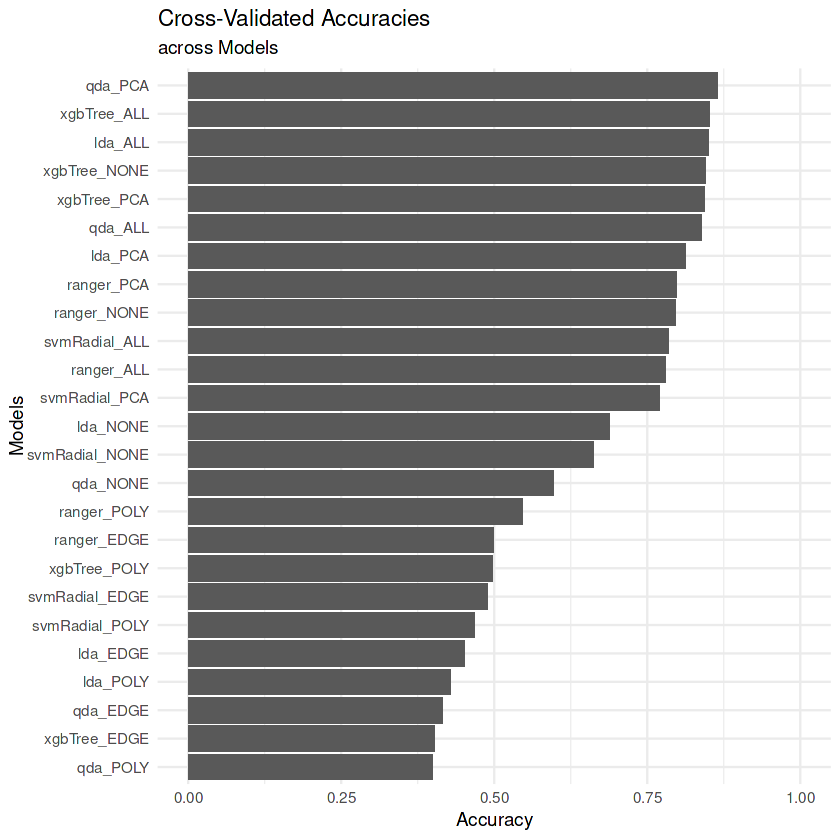

In [14]:
# ----------------- CV TRAINING -----------------

perf <- do.call(rbind, lapply(names(results), function(nm) {
  fit <- results[[nm]]
  data.frame(
    model      = nm,
    mean_acc   = mean(fit$resample$Accuracy, na.rm = TRUE),
    sd_acc     = sd(fit$resample$Accuracy,   na.rm = TRUE),
    mean_kappa = mean(fit$resample$Kappa,    na.rm = TRUE),
    stringsAsFactors = FALSE
  )
}))

# Table of CV performance
perf <- perf[order(-perf$mean_acc, -perf$mean_kappa, perf$model), ]
cat("Cross-validated performance:\n")
print(perf)

# Plot of CV performances
perf |> ggplot(aes(x = mean_acc, y = reorder(model, mean_acc))) +
        geom_col() +
        coord_cartesian(xlim = c(0,1)) +
        labs(
            title = "Cross-Validated Accuracies",
            subtitle = "across Models",
            x = "Accuracy",
            y = "Models",
        ) +
        theme_minimal()



# Summaries of CV performances
rs <- tryCatch(resamples(results), error = function(e) NULL)
if (!is.null(rs)) {
  cat("\nResample summary across models:\n")
  print(summary(rs))
}

Validation performance:
                    model  accuracy
Accuracy18    xgbTree_ALL 0.8833992
Accuracy5         qda_PCA 0.8774704
Accuracy19   xgbTree_NONE 0.8695652
Accuracy8         qda_ALL 0.8616601
Accuracy15    xgbTree_PCA 0.8596838
Accuracy3         lda_ALL 0.8458498
Accuracy14    ranger_NONE 0.8339921
Accuracy          lda_PCA 0.8201581
Accuracy10     ranger_PCA 0.8043478
Accuracy13     ranger_ALL 0.7865613
Accuracy23  svmRadial_ALL 0.7766798
Accuracy20  svmRadial_PCA 0.7490119
Accuracy4        lda_NONE 0.7094862
Accuracy24 svmRadial_NONE 0.6541502
Accuracy9        qda_NONE 0.6086957
Accuracy11    ranger_POLY 0.5830040
Accuracy16   xgbTree_POLY 0.5553360
Accuracy22 svmRadial_EDGE 0.5237154
Accuracy12    ranger_EDGE 0.4940711
Accuracy21 svmRadial_POLY 0.4723320
Accuracy17   xgbTree_EDGE 0.4624506
Accuracy2        lda_EDGE 0.4387352
Accuracy1        lda_POLY 0.4347826
Accuracy7        qda_EDGE 0.4347826
Accuracy6        qda_POLY 0.4071146


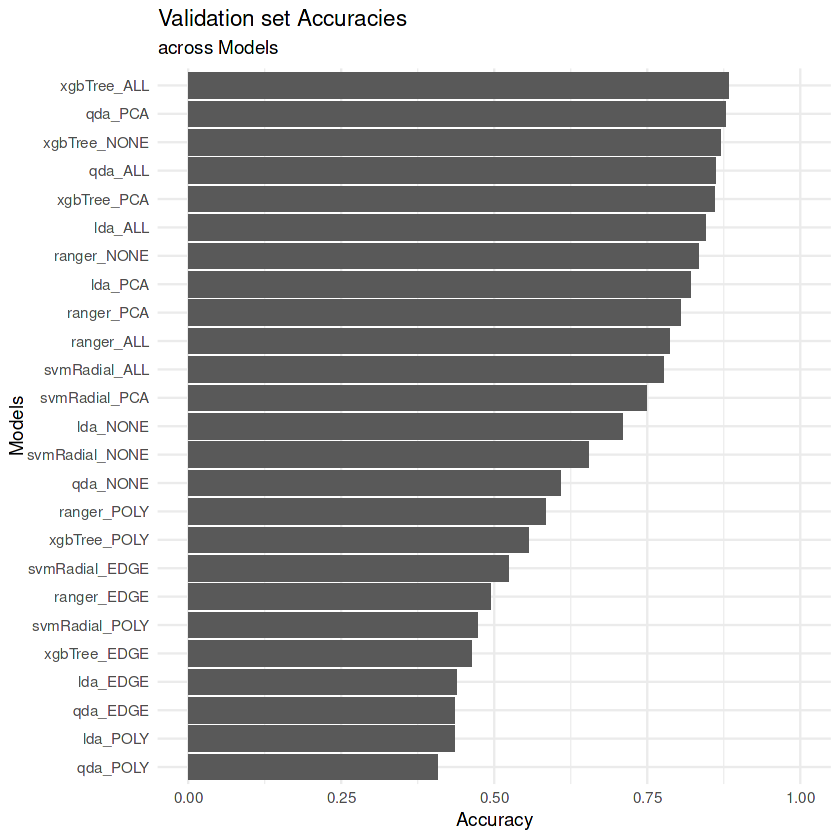

In [15]:
# ----------------- VALIDATION -----------------

# Performance on validation set
val <- do.call(rbind, lapply(names(acc), function(nm) {
  fit <- results[[nm]]
  data.frame(
    model      = nm,
    accuracy   = acc[[nm]],
    stringsAsFactors = FALSE
  )
}))

# Table of validation performance
val <- val[order(-val$accuracy), ]
cat("Validation performance:\n")
print(val)

# Plot of validation performances
val |> ggplot(aes(x = accuracy, y = reorder(model, accuracy))) +
        geom_col() +
        coord_cartesian(xlim = c(0,1)) +
        labs(
            title = "Validation set Accuracies",
            subtitle = "across Models",
            x = "Accuracy",
            y = "Models",
        ) +
        theme_minimal()

In [16]:
# ----------------- GET BEST MODEL -----------------

# Define best model               
best_name <- val$model[1]
best_fit  <- results[[best_name]]
cat("\nBest model by Validation:", best_name, "\n")
print(best_fit)
if (!is.null(best_fit$pred)) {
  cat("\nOut-of-fold confusion matrix for the best model:\n")
  print(confusionMatrix(factor(best_fit$pred$pred), factor(best_fit$pred$obs)))
} else {
  cat("",
      "")
}


parts   <- strsplit(best_name, "_")[[1]]          
featkey <- paste(parts[-1], collapse = "_")      

Xtest_best <- as.data.frame(feature_sets[[featkey]]$test)
colnames(Xtest_best) <- gsub(":", ".", colnames(Xtest_best))
pred_test_best_class <- predict(best_fit, newdata = Xtest_best)

pred_test_best_prob <- tryCatch(
  predict(best_fit, newdata = Xtest_best, type = "prob"),
  error = function(e) NULL
)


Best model by Validation: xgbTree_ALL 
eXtreme Gradient Boosting 

2032 samples
 121 predictor
   4 classes: 'anger', 'disgust', 'happy', 'sad' 

Pre-processing: centered (121), scaled (121) 
Resampling: Cross-Validated (5 fold, repeated 2 times) 
Summary of sample sizes: 1625, 1625, 1626, 1626, 1626, 1624, ... 
Resampling results:

  Accuracy   Kappa    
  0.8511289  0.7941166

Tuning parameter 'nrounds' was held constant at a value of 600
Tuning
 held constant at a value of 1
Tuning parameter 'subsample' was held
 constant at a value of 1
 

<h2 id = setup style = 'font-size:20px; background: linear-gradient(90deg, #B8B1D8, #B8B1D8, #E5E3F4); color: white; padding: 10px;  border-radius: 10px;'>
    Testing for significant differences between the models
</h2


Call:
summary.diff.resamples(object = diff(rs))

p-value adjustment: bonferroni 
Upper diagonal: estimates of the difference
Lower diagonal: p-value for H0: difference = 0

Accuracy 
               lda_PCA  lda_POLY  lda_EDGE  lda_ALL   lda_NONE  qda_PCA   qda_POLY  qda_EDGE  qda_ALL   qda_NONE 
lda_PCA                  0.384103  0.361703 -0.038153  0.124252 -0.052669  0.412645  0.396894 -0.025363  0.215038
lda_POLY       1.65e-08           -0.022400 -0.422256 -0.259851 -0.436772  0.028543  0.012791 -0.409466 -0.169064
lda_EDGE       5.77e-09 1.000000            -0.399856 -0.237451 -0.414372  0.050943  0.035191 -0.387066 -0.146665
lda_ALL        0.347768 2.79e-08  2.32e-08             0.162405 -0.014516  0.450798  0.435047  0.012790  0.253191
lda_NONE       0.000318 5.26e-07  6.90e-07  2.36e-05            -0.176921  0.288393  0.272642 -0.149615  0.090786
qda_PCA        0.000858 3.88e-09  3.48e-09  1.000000  1.61e-06             0.465314  0.449563  0.027306  0.267707
qda_POLY       9.5

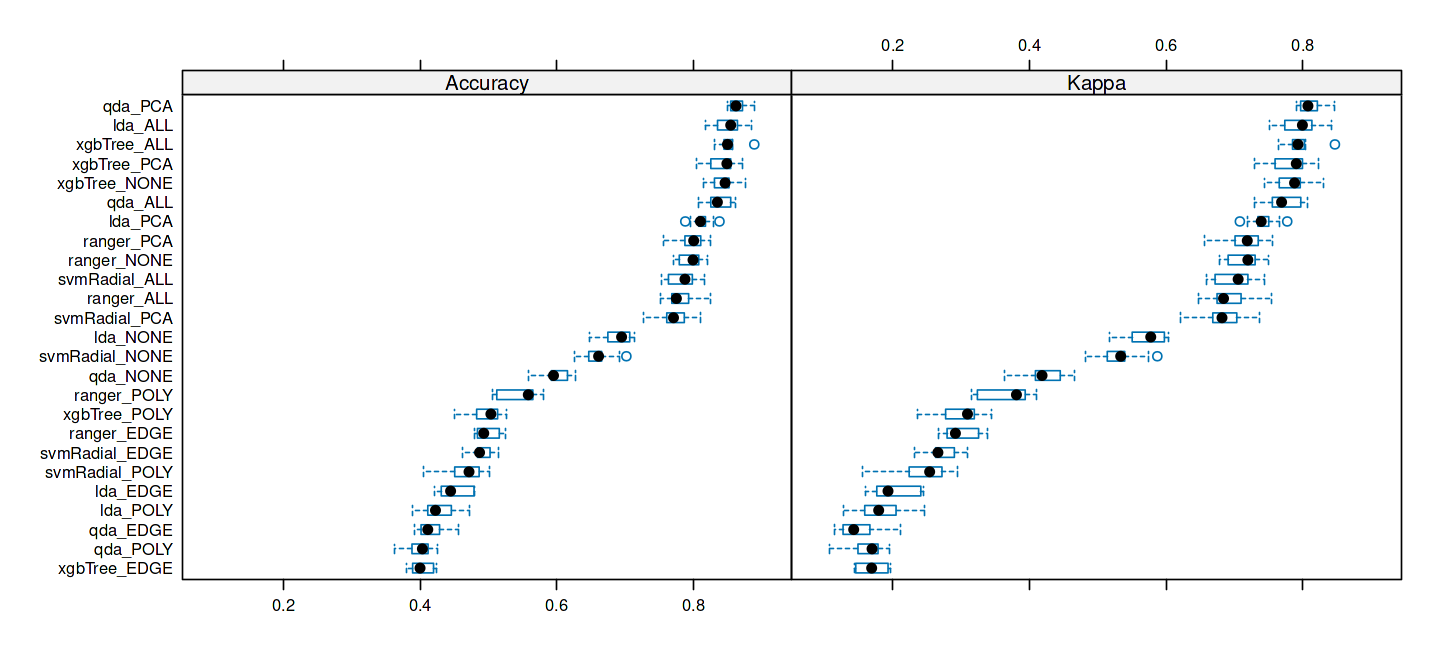

In [17]:
## Test significance of classifier accuracy differences
options(width=120, repr.plot.width=12, repr.plot.height=5.5, digits=5)

# Compute the table of pairwise comparisons
# CIs/p-values for paired differences (Accuracy and Kappa)
summary(diff(rs))

# box-and-whisker plot for the performance distribution
bwplot(rs)

<h1 id = setup style = 'font-size:30px; background: linear-gradient(90deg, #B8B1D8, #B8B1D8, #E5E3F4); color: white; padding: 10px;  border-radius: 10px;'>
    6. Formating Submission File
</h1


In [18]:
## Make predictions 
pred_best = predict(best_fit, newdata = as.data.frame(Xtest_best))
tibble(file = rownames(X_test), category = pred_best) %>% 
  write_csv(file = "submission.csv")

## Check result
cat(readLines("submission.csv", n = 20), sep = "\n")


best_fit

file,category
S010_004_00000017a.png,anger
S010_004_00000017b.png,sad
S010_004_00000017c.png,sad
S010_004_00000017d.png,sad
S010_004_00000017e.png,disgust
S010_004_00000017f.png,anger
S011_002_00000022a.png,sad
S011_002_00000022b.png,sad
S011_002_00000022c.png,disgust
S011_002_00000022d.png,sad
S011_002_00000022e.png,sad
S011_002_00000022f.png,sad
S011_005_00000018a.png,disgust
S011_005_00000018b.png,happy
S011_005_00000018c.png,sad
S011_005_00000018d.png,sad
S011_005_00000018e.png,disgust
S011_005_00000018f.png,sad
S011_006_00000013a.png,happy


eXtreme Gradient Boosting 

2032 samples
 121 predictor
   4 classes: 'anger', 'disgust', 'happy', 'sad' 

Pre-processing: centered (121), scaled (121) 
Resampling: Cross-Validated (5 fold, repeated 2 times) 
Summary of sample sizes: 1625, 1625, 1626, 1626, 1626, 1624, ... 
Resampling results:

  Accuracy  Kappa  
  0.85113   0.79412

Tuning parameter 'nrounds' was held constant at a value of 600
Tuning parameter 'max_depth' was held constant at
 parameter 'min_child_weight' was held constant at a value of 1
Tuning parameter 'subsample' was held constant at
 a value of 1

<h1 id = setup style = 'font-size:30px; background: linear-gradient(90deg, #B8B1D8, #B8B1D8, #E5E3F4); color: white; padding: 10px;  border-radius: 10px;'>
    7. Distribution of Labor
</h1

<div style="background-color:#F0EFFB;
            color:#333333;
            padding:12px 16px;
            border-radius:10px;
            margin:10px 0;">
   </b>  The Work was split equally, each person testing different model performances and creating different features. Martha tested how well histogram-based features work when using Lasso and Ridge regression. Anna evaluated how well PCA and polynomial and interaction transformation work using LDA and QDA. And Paulo focussed on histogram edge features, which he incorporated into Random Forest and boosted models. After the first deadline everybody worked on incorporating all features and models into one notebook. </div>

<h1 id = setup style = 'font-size:30px; background: linear-gradient(90deg, #B8B1D8, #B8B1D8, #E5E3F4); color: white; padding: 10px;  border-radius: 10px;'>
    References
</h1

<div style="background-color:#F0EFFB;
            color:#333333;
            padding:12px 16px;
            border-radius:10px;
            margin:10px 0;">
   </b>
Fiorentini, C., Schmidt, S., & Viviani, P. (2012). The Identification of Unfolding Facial Expressions. Perception, 41(5), 532-555. https://doi.org/10.1068/p7052  

Schmidt, K. L., Liu, Y., & Cohn, J. F. (2006). The role of structural facial asymmetry in asymmetry of peak facial expressions. Laterality, 11(6), 540-561. https://doi.org/10.1080/13576500600832758 </div>